# Configuration

In [40]:
# Optional setup for local development
%run _dev_setup.py

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
🔁 Autoreload is ON (IPython detected).
✅ Using latentflow from: /Users/iamsikun/Desktop/research/latentflow/src/latentflow


In [41]:
from typing import Optional
from dataclasses import fields, is_dataclass

In [42]:
import numpy as np
import pandas as pd

In [43]:
import matplotlib.pyplot as plt

In [44]:
from latentflow.config import load_experiment_config
from latentflow.sampler import sample_any_hmm
from latentflow.visualize import plot_hmm_series_with_states, plot_hmm_2d_states
from latentflow.analysis import ResultAnalyzer
from latentflow.models.hmm import * 
from latentflow.params import * 


# Step-by-step walkthrough

The sections below mirror `run_hmm_experiment.py` in order, with short excerpts
and explanations for each step.


## 1) Load Configuration

In [45]:
params, run_config = load_experiment_config('../configs/manual_gmmhmm.yaml')

In [46]:
print(f"Type: {type(params)}")
print(f"Number of features: {params.n_features}")
print(f"Number of states: {params.n_states}")
print(f"Instance: \n", params)

Type: <class 'latentflow.params.GMMHMMParams'>
Number of features: 2
Number of states: 2
Instance: 
 GMMHMMParams(start_probs=array([0.5, 0.5]), trans_mat=array([[0.9, 0.1],
       [0.2, 0.8]]), weights=array([[0.7, 0.3],
       [0.4, 0.6]]), means=array([[[0., 0.],
        [2., 2.]],

       [[5., 5.],
        [7., 7.]]]), covars=array([[[[1. , 0. ],
         [0. , 1. ]],

        [[0.5, 0. ],
         [0. , 0.5]]],


       [[[1. , 0. ],
         [0. , 1. ]],

        [[0.5, 0. ],
         [0. , 0.5]]]]))


## 2) RNG setup and optional history for AR models

**What happens:** the script uses a deterministic RNG and, when the model is
autoregressive, pre-samples a small history buffer.

**Why it matters:** ARHMMs need past observations to start the recursion cleanly.


In [47]:
T: int = run_config.get("T", 200)
seed: int = run_config.get("seed", 42)
rng: np.random.Generator = np.random.default_rng(seed)

history: Optional[np.ndarray] = None
if hasattr(params, "order") and params.order > 0:
    history = rng.normal(scale=0.5, size=(params.order, params.n_features))

## 3) Sampling a synthetic trajectory

**What happens:** the sampler generates true hidden states and observations for
any supported HMM type.

**Why it matters:** this creates a controlled dataset where we *know* the ground
truth, enabling clean comparisons between true and learned parameters.


In [48]:
true_states, obs = sample_any_hmm(
    params,
    T=T,
    rng=rng,
    history=history,
)

In [49]:
pd.DataFrame({
    **{f'obs_{i}': obs[:, i] for i in range(obs.shape[1])},
    'true_states': true_states,
})

,obs_0,obs_1,true_states
0,7.530649,7.665080,1
1,2.090397,1.776383,0
2,0.879398,0.777792,0
3,2.330579,1.392388,0
4,0.878450,-0.049926,0
...,...,...,...
195,2.312927,2.883647,0
196,0.636906,0.340791,0
197,-0.556192,-1.279841,0
198,2.961114,2.180463,0


## 4) Model selection and initialization

**What happens:** the script maps the parameter dataclass to its corresponding
model class, then builds init kwargs that match the model family.


**Why it matters:** this keeps the script "family-agnostic" while still passing
the right constructor arguments for each variant (Gaussian, GMM, AR).


In [50]:
def get_model_class(params):
    if isinstance(params, GaussianHMMParams):
        return GaussianHMM
    elif isinstance(params, GMMHMMParams):
        return GMMHMM
    elif isinstance(params, GaussianARHMMParams):
        return GaussianARHMM
    elif isinstance(params, GMMARHMMParams):
        return GMMARHMM
    else:
        raise TypeError(f"Unsupported parameter type: {type(params)}")

In [51]:
model_cls = get_model_class(params)

init_kwargs = {
    "n_components": params.n_states,
    "random_state": seed,
}
if hasattr(params, "n_mixtures"):
    init_kwargs["n_mixtures"] = params.n_mixtures
if hasattr(params, "order"):
    init_kwargs["order"] = params.order

model = model_cls(**init_kwargs)

In [52]:
print(f"Model class: {model_cls.__name__}")
print(f"Init kwargs: {init_kwargs}")
print(f"Model instance: \n", model)

Model class: GMMHMM
Init kwargs: {'n_components': 2, 'random_state': 42, 'n_mixtures': 2}
Model instance: 


## 5) Fit and predict

**What happens:** the model is trained with EM, then hidden states are inferred
from the fitted model.

**Why it matters:** `fit()` learns parameters; `predict()` recovers the most likely
state sequence for the observed data.


In [53]:
model.fit(obs, verbose=True)
pred_states = model.predict(obs)

EM iter 001: loglik=-823.050494
EM iter 002: loglik=-753.311430
EM iter 003: loglik=-708.607707
EM iter 004: loglik=-683.925581
EM iter 005: loglik=-678.710514
EM iter 006: loglik=-676.769495
EM iter 007: loglik=-675.690114
EM iter 008: loglik=-674.859013
EM iter 009: loglik=-674.000449
EM iter 010: loglik=-672.964424
EM iter 011: loglik=-671.630730
EM iter 012: loglik=-669.910822
EM iter 013: loglik=-667.737115
EM iter 014: loglik=-665.194858
EM iter 015: loglik=-662.821293
EM iter 016: loglik=-661.341017
EM iter 017: loglik=-660.780151
EM iter 018: loglik=-660.632096
EM iter 019: loglik=-660.587698
EM iter 020: loglik=-660.562658
EM iter 021: loglik=-660.541238
EM iter 022: loglik=-660.520644
EM iter 023: loglik=-660.500141
EM iter 024: loglik=-660.479323
EM iter 025: loglik=-660.457834
EM iter 026: loglik=-660.435303
EM iter 027: loglik=-660.411311
EM iter 028: loglik=-660.385354
EM iter 029: loglik=-660.356796
EM iter 030: loglik=-660.324794
EM iter 031: loglik=-660.288182
EM iter 

In [54]:
pd.DataFrame({
    **{f'obs_{i}': obs[:, i] for i in range(obs.shape[1])},
    'true_states': true_states,
    'pred_states': pred_states,
})

,obs_0,obs_1,true_states,pred_states
0,7.530649,7.665080,1,1
1,2.090397,1.776383,0,0
2,0.879398,0.777792,0,0
3,2.330579,1.392388,0,0
4,0.878450,-0.049926,0,0
...,...,...,...,...
195,2.312927,2.883647,0,0
196,0.636906,0.340791,0,0
197,-0.556192,-1.279841,0,0
198,2.961114,2.180463,0,0


In [55]:
model.state_variables()

## 6) Visualization (static plots)

**What happens:** the script produces side-by-side time-series plots of true and
predicted state sequences. When both true and predicted parameters are available,
`plot_hmm_series_with_states` remaps the predicted labels using parameter-based
matching (symmetric KL between per-state Gaussians).

**Why it matters:** the label permutation ambiguity is handled consistently, so
visual comparisons are meaningful across runs.


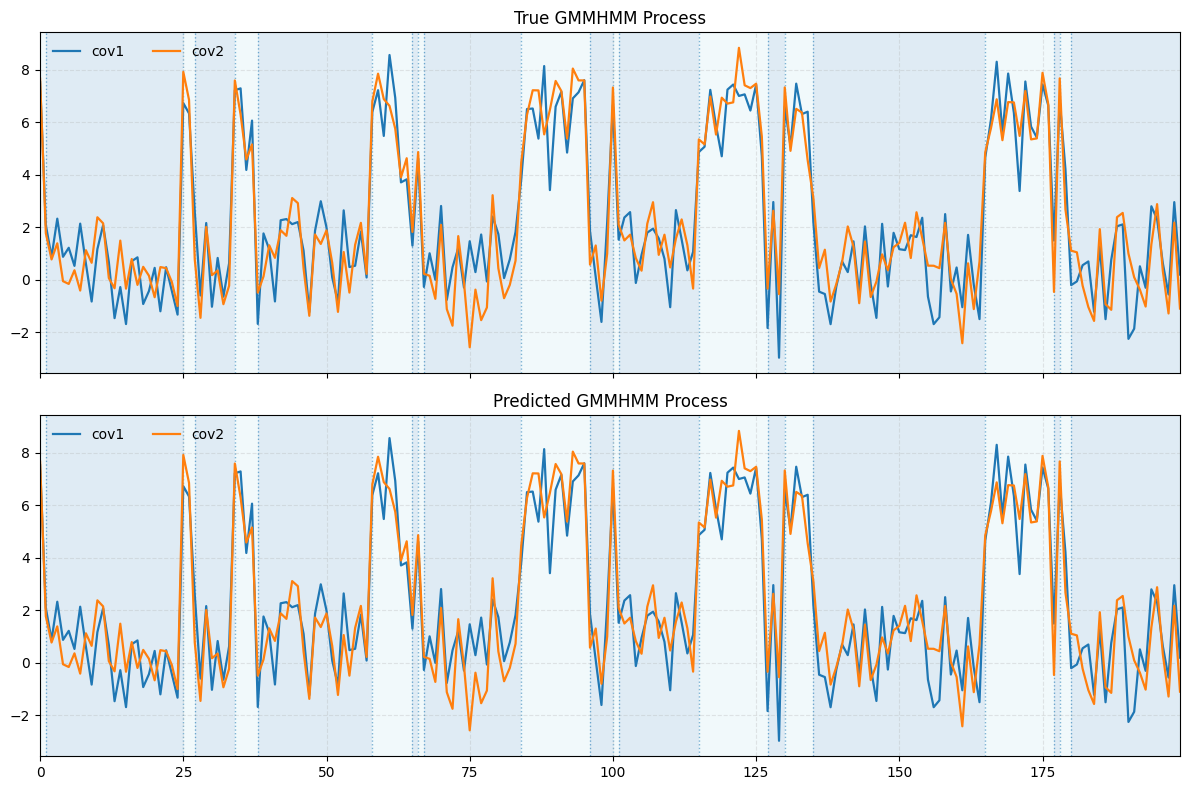

In [30]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(12, 8))

model_name_display = type(params).__name__.replace("Params", "")

_, axes[0] = plot_hmm_series_with_states(
    list(range(T)),
    obs,
    true_states,
    covariate_names=[f"cov{i+1}" for i in range(params.n_features)],
    title=f"True {model_name_display} Process",
    annotate_states=False,
    boundary_markers=True,
    ax=axes[0],
)

_, axes[1] = plot_hmm_series_with_states(
    list(range(T)),
    obs,
    pred_states,
    true_states=true_states,
    pred_params=model.params,
    true_params=params,
    covariate_names=[f"cov{i+1}" for i in range(params.n_features)],
    title=f"Predicted {model_name_display} Process",
    annotate_states=False,
    boundary_markers=True,
    ax=axes[1],
)

plt.tight_layout()
plt.show()

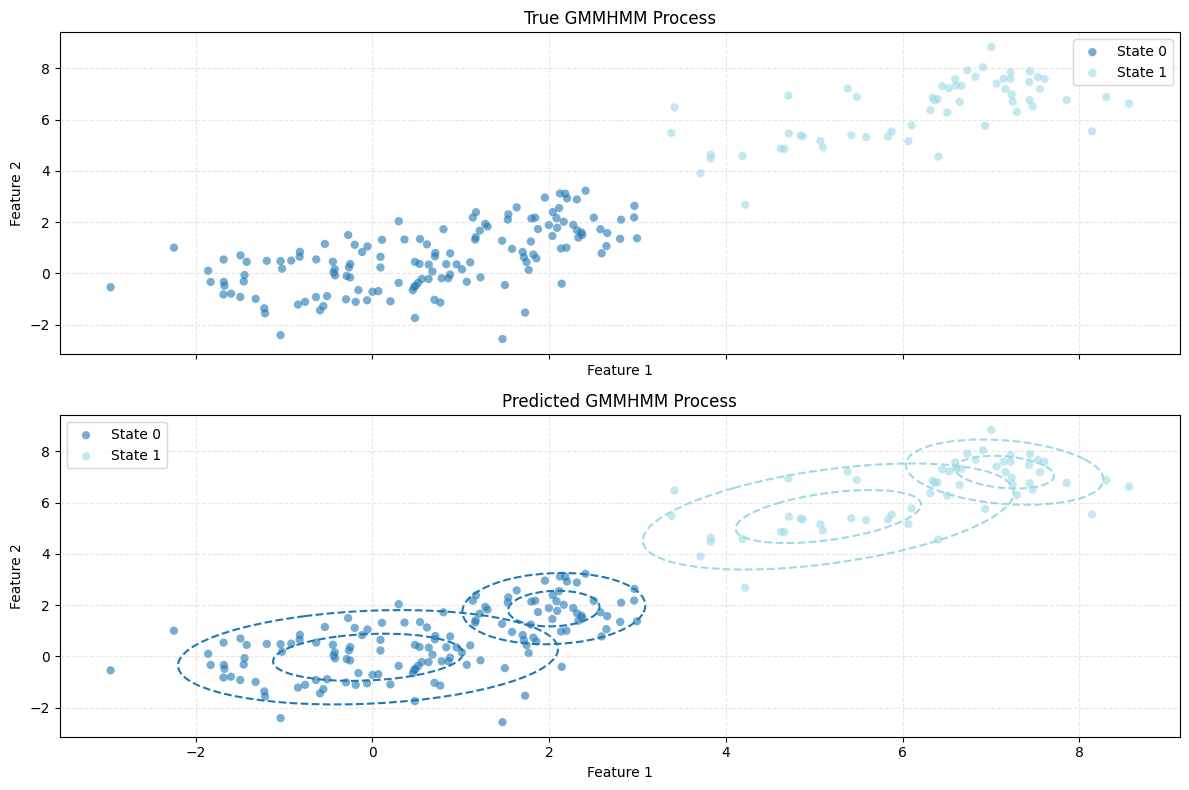

In [ ]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(12, 8))

model_name_display = type(params).__name__.replace("Params", "")

_, axes[0] = plot_hmm_2d_states(
    obs,
    true_states,
    pred_params=params,
    title=f"True {model_name_display} Process",
    ax=axes[0],
)

_, axes[1] = plot_hmm_2d_states(
    obs,
    pred_states,
    true_states=true_states,
    pred_params=model.params,
    true_params=params,
    title=f"Predicted {model_name_display} Process",
    ax=axes[1],
)

plt.tight_layout()
plt.show()

## 7) Parameter metrics


In [31]:
def _flatten_params_for_metrics(param_obj) -> dict[str, float]:
    """
    Flatten a parameter dataclass into a mapping of label -> value.

    This preserves field ordering and uses C-order flattening for arrays so that
    true and estimated parameters align for metric computation.
    """
    if not is_dataclass(param_obj):
        raise TypeError("Parameter object must be a dataclass.")

    flat: dict[str, float] = {}
    for field in fields(param_obj):
        value = getattr(param_obj, field.name)
        arr = np.asarray(value, dtype=float).ravel()
        for idx, val in enumerate(arr):
            flat[f"{field.name}[{idx}]"] = float(val)
    return flat

In [32]:
analyzer = ResultAnalyzer()

true_flat = _flatten_params_for_metrics(params)
est_flat = _flatten_params_for_metrics(model.params)
metrics_table = analyzer.evaluate_parameters(true_flat, est_flat)
metrics_table["state_accuracy"] = float(np.mean(pred_states == true_states))
if model.loglik is not None:
    metrics_table["log_likelihood"] = float(model.loglik)

In [33]:
metrics_table

{'rmse': 0.2136865586867292,
 'mae': 0.1495222406513742,
 'mape': 19.395544247059718,
 'state_accuracy': 1.0,
 'log_likelihood': -651.6293669525172}

## 8) Outputs to expect

Depending on `run_config` you can get:
- A PNG (or other) static plot via `output_file`.
- Console-printed metrics (parameter errors, state accuracy, log-likelihood).
